# **Phân tích và So sánh Mô hình Hồi quy theo Phân khúc (Low vs High)**

Notebook này thực hiện 2 giai đoạn:
1.  **Giai đoạn 1: Train & Save**: Huấn luyện mô hình -> Dự đoán -> Lưu kết quả ra file CSV.
2.  **Giai đoạn 2: Load & Compare**: Đọc file CSV đã lưu -> So sánh hiệu suất & Vẽ biểu đồ.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thêm đường dẫn thư mục hiện tại để import models.py
sys.path.append(os.path.abspath("../src"))

from models_v2 import (
    load_data,
    split_low_high_hard,
    train_lgbm,
    train_svr,
    train_knn,
    train_elasticnet,
    train_rf,
    train_xgboost,
    run_model_comparison,
    plot_feature_importance
)

# Thiết lập hiển thị pandas
pd.set_option('display.max_columns', None)

## **GIAI ĐOẠN 1: TRAIN MODEL & SAVE PREDICTIONS**

In [2]:
print("--- BẮT ĐẦU GIAI ĐOẠN 1 ---")

train_df, test_df = load_data()

# Tách Low/High cho cả Train và Test
train_low, train_high = split_low_high_hard(train_df, threshold=2.0)
test_low, test_high = split_low_high_hard(test_df, threshold=2.0)

# Chuẩn bị X, y
X_train_low = train_low.drop(columns=['quantity_sold'])
y_train_low = train_low['quantity_sold']
X_test_low = test_low.drop(columns=['quantity_sold'])
y_test_low = test_low['quantity_sold']

X_train_high = train_high.drop(columns=['quantity_sold'])
y_train_high = train_high['quantity_sold']
X_test_high = test_high.drop(columns=['quantity_sold'])
y_test_high = test_high['quantity_sold']

print(f"Train Low: {X_train_low.shape}, Train High: {X_train_high.shape}")

--- BẮT ĐẦU GIAI ĐOẠN 1 ---
Split Data: Low (<2.0): 8480 | High (>=2.0): 7368
Split Data: Low (<2.0): 2078 | High (>=2.0): 1885
Train Low: (8480, 53), Train High: (7368, 53)


### **1.1. Train Low Segment (Low < 2)**


------------------------------------------------------------
HUẤN LUYỆN MODEL LOW: LightGBM
------------------------------------------------------------
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'subsample': 1.0, 'num_leaves': 50, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


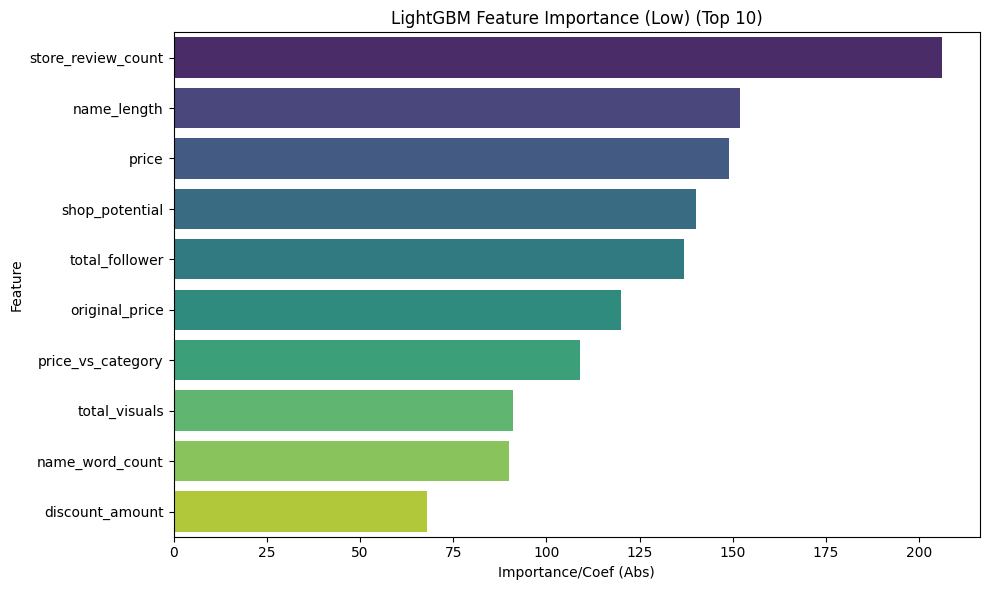


------------------------------------------------------------
HUẤN LUYỆN MODEL LOW: SVR
------------------------------------------------------------
Bước 1: Feature selection bằng Random Forest...
  Đã chọn 20 features quan trọng nhất.
Bước 2: GridSearchCV cho SVR...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best params: {'svr__C': 1, 'svr__epsilon': 0.2, 'svr__kernel': 'rbf'}
Best score (MSE): 0.258363
Bước 3: Permutation importance để tinh chỉnh features...
Refined còn: 20 features (từ 20)

------------------------------------------------------------
HUẤN LUYỆN MODEL LOW: KNN
------------------------------------------------------------
Bước 1: Feature selection (RF Top-K)...
  Đã chọn 40 features.
Bước 2: GridSearchCV cho KNN...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
  Best params: {'knn__n_neighbors': 21, 'knn__p': 1, 'knn__weights': 'distance'}

Đã lưu 3 file CSV cho Low Segment vào ../data/predicted/


In [3]:
# --- LightGBM ---
model_lgbm, feats_lgbm = train_lgbm(X_train_low, y_train_low)
pred_lgbm = model_lgbm.predict(X_test_low[feats_lgbm])
plot_feature_importance(model_lgbm, feature_names=feats_lgbm, title="LightGBM Feature Importance (Low)")
pd.DataFrame({'quantity_sold_ground_truth': y_test_low.values, 'quantity_sold_predicted': pred_lgbm}).to_csv("../data/predicted/lgbm_predictions.csv", index=False)

# --- SVR ---
model_svr, feats_svr = train_svr(X_train_low, y_train_low)
pred_svr = model_svr.predict(X_test_low[feats_svr])
pd.DataFrame({'quantity_sold_ground_truth': y_test_low.values, 'quantity_sold_predicted': pred_svr}).to_csv("../data/predicted/svr_predictions.csv", index=False)

# --- KNN ---
model_knn, feats_knn = train_knn(X_train_low, y_train_low)
pred_knn = model_knn.predict(X_test_low[feats_knn])
pd.DataFrame({'quantity_sold_ground_truth': y_test_low.values, 'quantity_sold_predicted': pred_knn}).to_csv("../data/predicted/knn_predictions.csv", index=False)

print("\nĐã lưu 3 file CSV cho Low Segment vào ../data/predicted/")

### **1.2. Train High Segment (High >= 2)**


------------------------------------------------------------
HUẤN LUYỆN MODEL HIGH: ElasticNet (Refined)
------------------------------------------------------------
Bước 1: ElasticNetCV tìm tham số tối ưu...
  Best: alpha=0.0001, l1_ratio=0.3
Bước 2: Chọn features dựa trên hệ số (Coefficient)...
  Selected (Sơ bộ): 50 features
Bước 3: Tinh chỉnh features (Refinement)...
  Refined còn: 37 features
Bước 4: Train model cuối cùng...


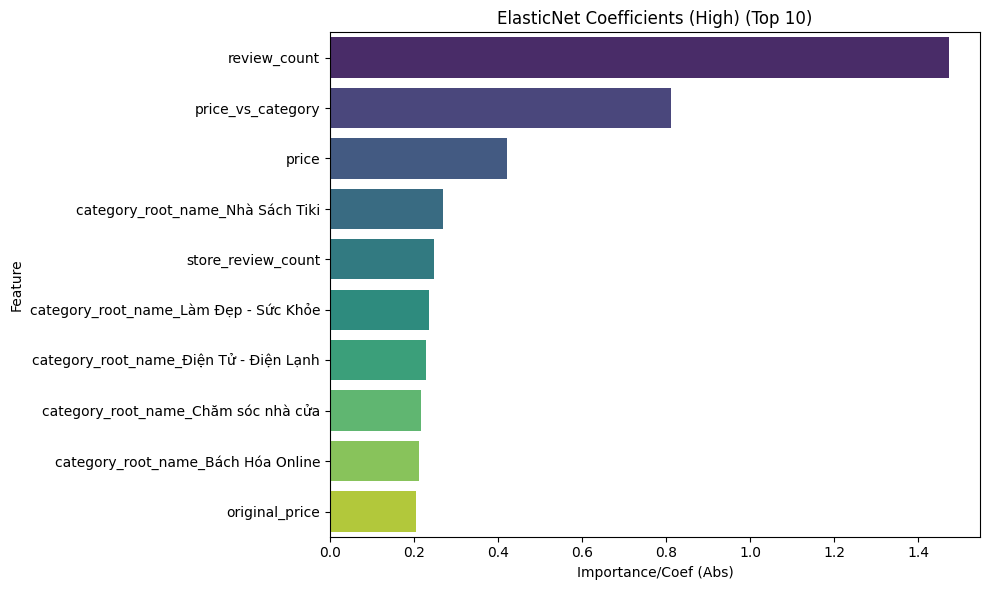


------------------------------------------------------------
HUẤN LUYỆN MODEL HIGH: Random Forest (Refined)
------------------------------------------------------------
Bước 1: GridSearchCV...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
  Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 500}
  Best score (R2): 0.834969
Bước 2: Tinh chỉnh features dựa trên importance...
  Refined còn: 42 features
Bước 3: Re-training với refined features...
  -> Sử dụng model tinh chỉnh.


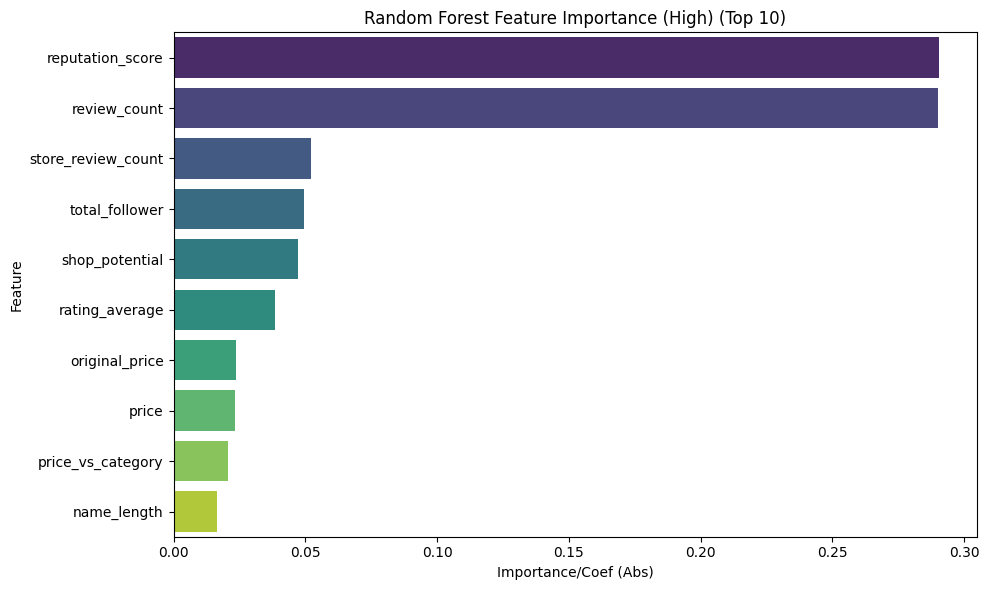


------------------------------------------------------------
HUẤN LUYỆN MODEL HIGH: XGBoost (Refined)
------------------------------------------------------------
Bước 1: Initial training để lọc feature...
Bước 2: RandomizedSearchCV...
  Best params: {'subsample': 0.6, 'n_estimators': 1000, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Bước 3: Tinh chỉnh & Train final model...
  Refined còn: 42 features


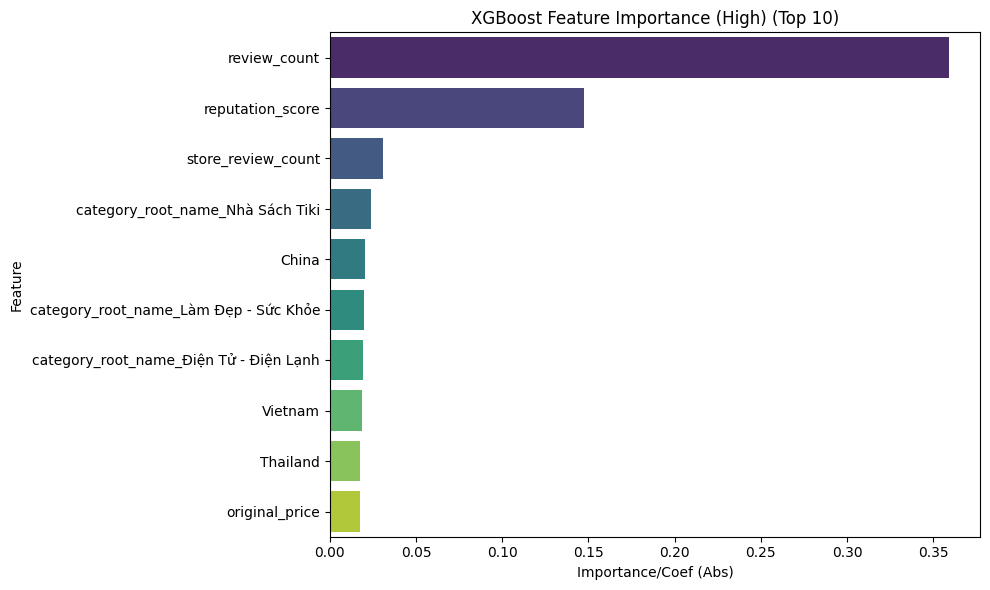


Đã lưu 3 file CSV cho High Segment vào ../data/predicted/


In [4]:
# --- ElasticNet ---
model_enet, feats_enet = train_elasticnet(X_train_high, y_train_high)
pred_enet = model_enet.predict(X_test_high[feats_enet])
plot_feature_importance(model_enet, feature_names=feats_enet, title="ElasticNet Coefficients (High)")
pd.DataFrame({'quantity_sold_ground_truth': y_test_high.values, 'quantity_sold_predicted': pred_enet}).to_csv("../data/predicted/elasticnet_predictions.csv", index=False)

# --- Random Forest ---
model_rf, feats_rf = train_rf(X_train_high, y_train_high)
pred_rf = model_rf.predict(X_test_high[feats_rf])
plot_feature_importance(model_rf, feature_names=feats_rf, title="Random Forest Feature Importance (High)")
pd.DataFrame({'quantity_sold_ground_truth': y_test_high.values, 'quantity_sold_predicted': pred_rf}).to_csv("../data/predicted/rf_predictions.csv", index=False)

# --- XGBoost ---
model_xgb, feats_xgb = train_xgboost(X_train_high, y_train_high)
pred_xgb = model_xgb.predict(X_test_high[feats_xgb])
plot_feature_importance(model_xgb, feature_names=feats_xgb, title="XGBoost Feature Importance (High)")
pd.DataFrame({'quantity_sold_ground_truth': y_test_high.values, 'quantity_sold_predicted': pred_xgb}).to_csv("../data/predicted/xgboost_predictions.csv", index=False)

print("\nĐã lưu 3 file CSV cho High Segment vào ../data/predicted/")

## **GIAI ĐOẠN 2: LOAD KẾT QUẢ TỪ FILE & SO SÁNH**

--- BẮT ĐẦU GIAI ĐOẠN 2 ---

--- Bảng So Sánh Hiệu Suất (Low) ---
   Model      MAE     RMSE       R2
LightGBM 0.358898 0.465195 0.485254
     SVR 0.383887 0.496071 0.414657
     KNN 0.355082 0.481246 0.449119
Đã lưu biểu đồ metrics: ../data/images/comparison_metrics_low.png


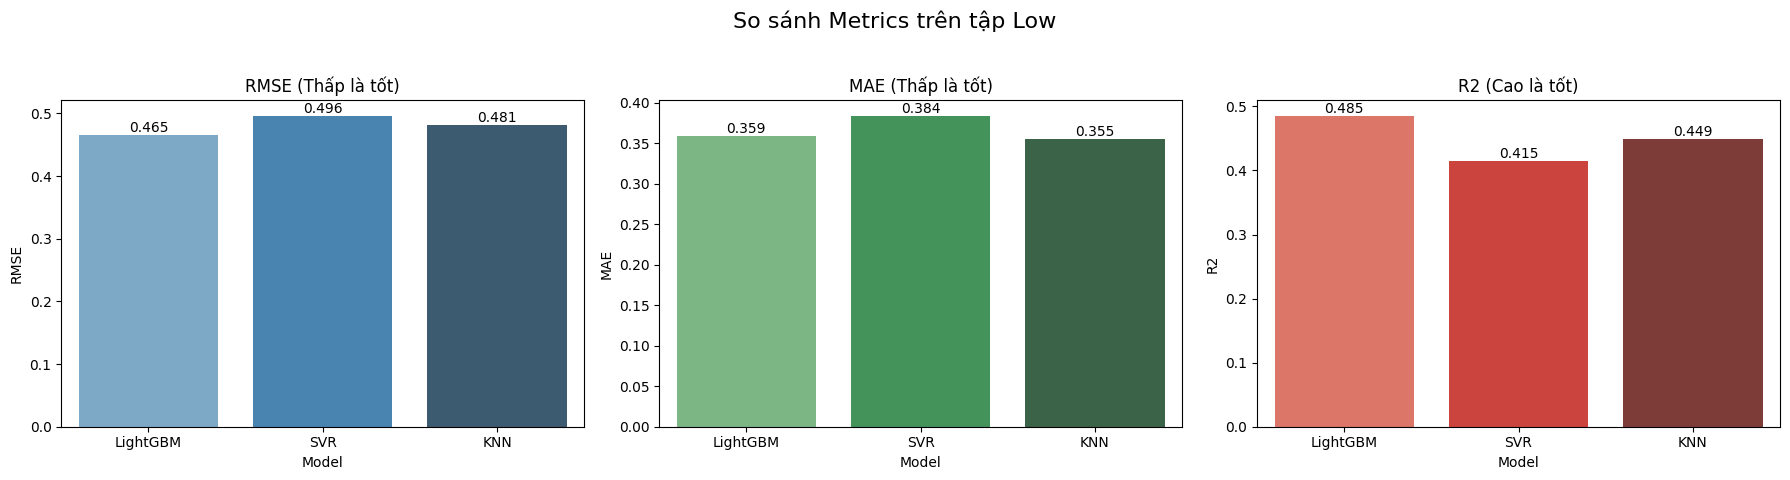

Đã lưu biểu đồ scatter: ../data/images/comparison_scatter_low.png


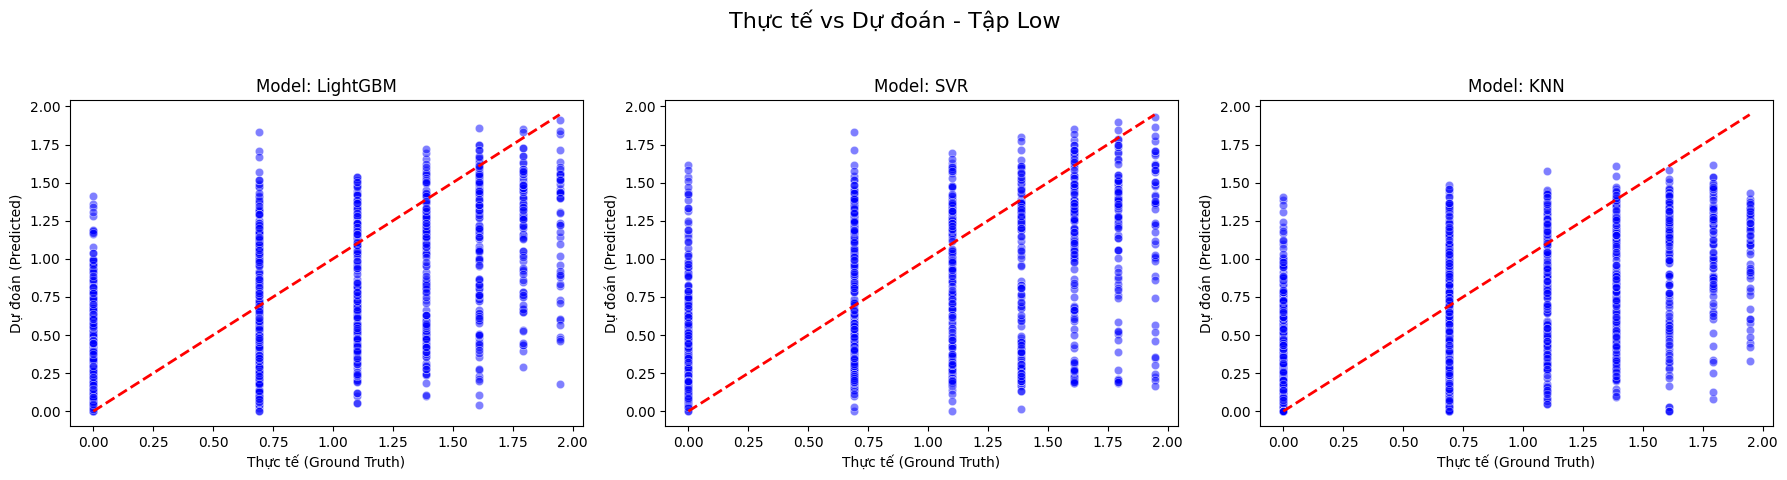


--- Bảng So Sánh Hiệu Suất (High) ---
       Model      MAE     RMSE       R2
  ElasticNet 0.529221 0.768306 0.809099
RandomForest 0.502976 0.698154 0.842369
     XGBoost 0.487275 0.690635 0.845746
Đã lưu biểu đồ metrics: ../data/images/comparison_metrics_high.png


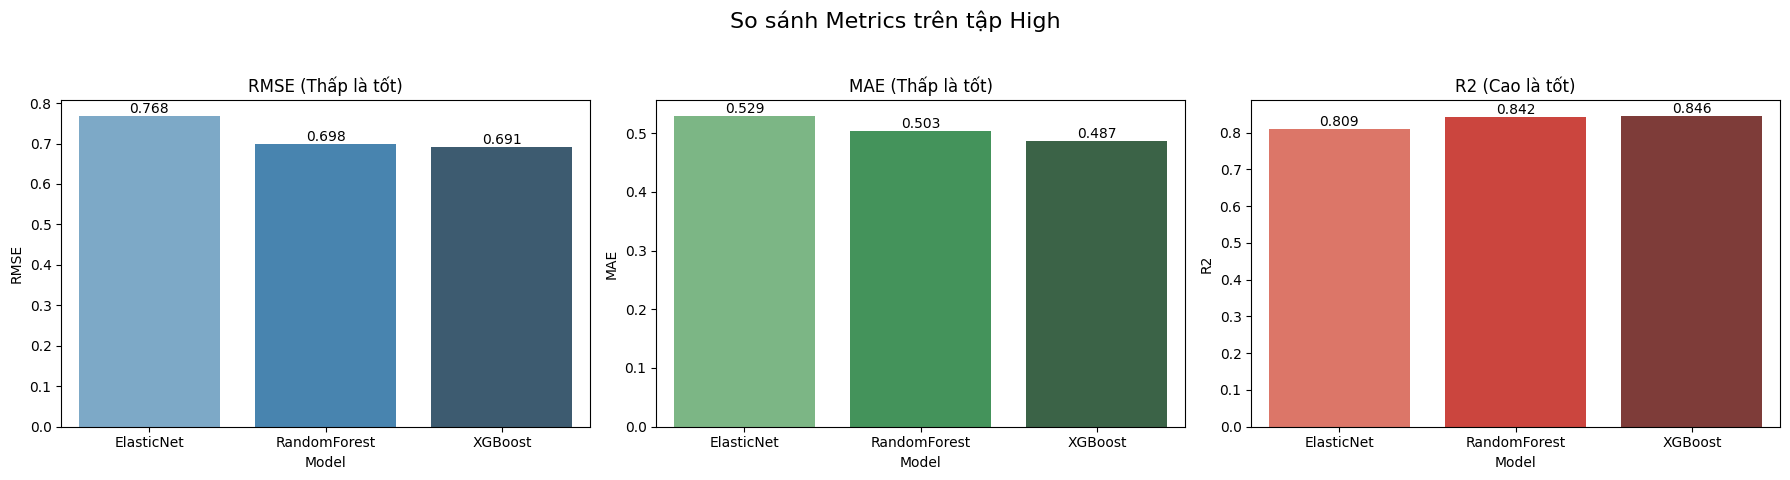

Đã lưu biểu đồ scatter: ../data/images/comparison_scatter_high.png


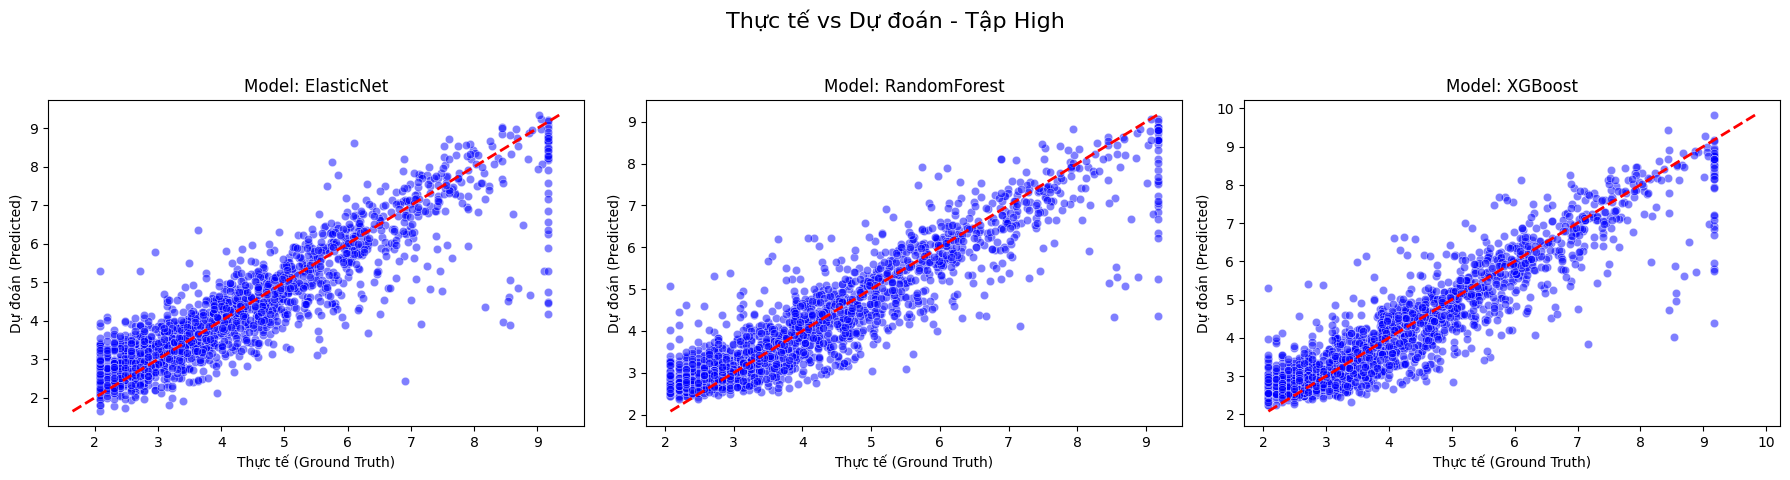

In [5]:
print("--- BẮT ĐẦU GIAI ĐOẠN 2 ---")

# Hàm đọc file
def read_pred_csv(name, path):
    if not os.path.exists(path):
        print(f"Không tìm thấy file: {path}")
        return None
    df = pd.read_csv(path)
    return df

# -----------------------------------------------------
# So sánh Low Segment
# -----------------------------------------------------
low_files = {
    'LightGBM': "../data/predicted/lgbm_predictions.csv",
    'SVR': "../data/predicted/svr_predictions.csv",
    'KNN': "../data/predicted/knn_predictions.csv"
}

results_low = {}
for name, path in low_files.items():
    df = read_pred_csv(name, path)
    if df is not None:
        results_low[name] = {
            'y_true': df['quantity_sold_ground_truth'],
            'y_pred': df['quantity_sold_predicted']
        }

if results_low:
    metrics_low = run_model_comparison(results_low, dataset_name="Low")

# -----------------------------------------------------
# So sánh High Segment
# -----------------------------------------------------
high_files = {
    'ElasticNet': "../data/predicted/elasticnet_predictions.csv",
    'RandomForest': "../data/predicted/rf_predictions.csv",
    'XGBoost': "../data/predicted/xgboost_predictions.csv"
}

results_high = {}
for name, path in high_files.items():
    df = read_pred_csv(name, path)
    if df is not None:
        results_high[name] = {
            'y_true': df['quantity_sold_ground_truth'],
            'y_pred': df['quantity_sold_predicted']
        }

if results_high:
    metrics_high = run_model_comparison(results_high, dataset_name="High")

## **7. SO SÁNH CÁC MÔ HÌNH (Low Segment)**

**Kết quả tổng hợp (Low):**

| Mô hình | R² (Test) | RMSE (Test) |
| :--- | :--- | :--- |
| LightGBM | ... | ... |
| SVR | ... | ... |
| KNN | ... | ... |

**Nhận xét (Low):**

- ...
- ...


## **8. SO SÁNH CÁC MÔ HÌNH (High Segment)**

**Kết quả tổng hợp (High):**

| Mô hình | R² (Test) | RMSE (Test) |
| :--- | :--- | :--- |
| ElasticNet | ... | ... |
| Random Forest | ... | ... |
| XGBoost | ... | ... |

**Nhận xét (High):**

- ...
- ...

---